In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

def plot_g_bprp(fits_file, cluster_name, mode):

    # Load Data
    data = fits.open(fits_file)[1].data

    # Get necessary data
    G   = data["GAIAEDR3_G_CORRECTED"]
    BP  = data["GAIAEDR3_BP"]
    RP  = data["GAIAEDR3_RP"]

    BP_RP = BP - RP

    # Uncertainties
    G_err  = data["GAIAEDR3_G_ERR"]
    BP_RP_err = np.sqrt(data["GAIAEDR3_BP_ERR"]**2 + data["GAIAEDR3_RP_ERR"]**2)
    
 
    if mode == "membership":
        MEM = data["MEMBOOL"] 
        members = (MEM == 1) | (MEM == True)
        nonmembers = ~members

        # Make the plot

        plt.figure(figsize=(6, 6))

        plt.scatter(BP_RP[nonmembers], G[nonmembers],
                    s=4, alpha=0.2, label="Non-members", color='tab:blue')

        plt.scatter(BP_RP[members], G[members],
                    s=8, alpha=0.8, label="Members", color='tab:orange')

    elif mode == "hdbscan_cluster":
        MEM = data["MEMBOOL"] 
        HDB = data["HDBscan_Cluster"]

        HDBOne = HDB == -1
        HDBTwo = HDB == -2

        plt.figure(figsize=(6, 6))
        
        plt.scatter(BP_RP[HDBOne], G[HDBOne],
                    s=4, alpha=0.2, label="HDBscan_Cluster = -1", color='tab:purple')


        plt.errorbar(
            BP_RP[HDBTwo], G[HDBTwo],
            xerr=BP_RP_err[HDBTwo],
            yerr=G_err[HDBTwo],
            fmt='o',
            markersize=4,
            alpha=0.8,
            elinewidth=0.5,
            capsize=0,
            color= 'tab:green',
            label="HDBscan_Cluster = -2"
        )

    elif mode == "mix":
        MEM = data["MEMBOOL"] 
        members = (MEM == 1) | (MEM == True)
        nonmembers = (MEM == 0) | (MEM == False)
        HDB = data["HDBscan_Cluster"]
        HDBTwo = HDB == -2
        # Make the plot

        plt.figure(figsize=(6, 6))

        plt.scatter(BP_RP[nonmembers], G[nonmembers],
                    s=4, alpha=0.2, label="Non-members", color='tab:blue')

        plt.scatter(BP_RP[members], G[members],
                    s=8, alpha=0.8, label="Members", color='tab:orange')
        plt.errorbar(
            BP_RP[HDBTwo], G[HDBTwo],
            xerr=BP_RP_err[HDBTwo],
            yerr=G_err[HDBTwo],
            fmt='o',
            markersize=4,
            alpha=0.8,
            elinewidth=0.5,
            capsize=0,
            color='tab:green',
            label="HDBscan_Cluster = -2"
        )
    else:
        raise ValueError("mode must be 'membership' or 'hdbscan_cluster' or 'mix'")

    plt.xlabel("BP − RP")
    plt.ylabel("G")
    plt.ylim(8, 22)
    plt.xlim(-0.5, 3)
    plt.gca().invert_yaxis()
    plt.title(f"{cluster_name} G vs BP − RP")
    plt.legend()

    plt.show()


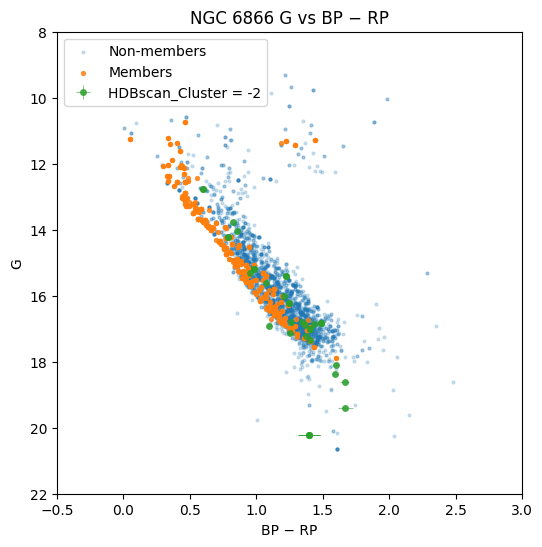

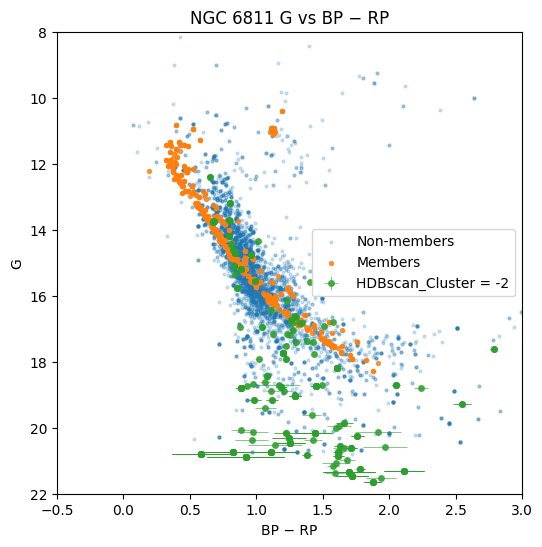

In [12]:
plot_g_bprp("rcat_ngc6866_v0.fits", "NGC 6866", "mix")
plot_g_bprp("rcat_ngc6811_v0.fits", "NGC 6811", "mix")